In [2]:
import pandas as pd
import pyodbc
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Supprimer les warnings
warnings.filterwarnings("ignore")

# Connexion SQL Server
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};SERVER={server};DATABASE={database};"
    f"UID={username};PWD={password};TrustServerCertificate=yes;MARS_Connection=yes;",
    timeout=5
)
print("✅ Connexion réussie à la base DW_Fico")


✅ Connexion réussie à la base DW_Fico


In [19]:
query = """
SELECT 
    c.name AS Column_Name,
    tp.name AS Data_Type,
    c.max_length AS Max_Length,
    c.is_nullable AS Is_Nullable
FROM sys.columns AS c
JOIN sys.types AS tp ON c.user_type_id = tp.user_type_id
WHERE c.object_id = OBJECT_ID('dbo.SAP_Fico')
ORDER BY c.column_id;
"""

# Exécuter la requête et charger dans un DataFrame Pandas
df_columns = pd.read_sql(query, conn)

# Afficher les résultats
print(df_columns)

Empty DataFrame
Columns: [Column_Name, Data_Type, Max_Length, Is_Nullable]
Index: []


In [20]:
tables_query = "SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE = 'BASE TABLE'"
df= pd.read_sql(tables_query, conn)
print("📌 Tables disponibles :")
print(df)

📌 Tables disponibles :
         TABLE_NAME
0    dim_entreprise
1    sous_FACT_Fico
2   dim_fournisseur
3       Dim_clients
4          Dim_Date
5         FACT_Fico
6           dim_geo
7       sysdiagrams
8          dim_prod
9      dim_invoices
10      dim_dispute


In [21]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
# Load the FACT_Fico table
query = "SELECT * FROM FACT_Fico"
FACT_Fico = pd.read_sql(query, conn)

# Verify the columns
print("📋 Colonnes disponibles dans FACT_Fico :")
print(FACT_Fico.columns)

# 🎯 Variables
X = FACT_Fico[['Revenu_monoprix']]
y = FACT_Fico['Investissement_dans_les_Actifs']
# 🧪 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⚙️ Modèle XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# 🧾 Prédictions
y_pred = xgb_model.predict(X_test)

# 📊 Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


📋 Colonnes disponibles dans FACT_Fico :
Index(['code_Fico', 'FK_client', 'FK_fournisseur', 'FK_entreprise',
       'FK_address', 'FK_Invoice', 'FK_product', 'FK_dispute',
       'FK_DatePayement', 'FK_DueDate', 'FK_Dispute_Date', 'FK_ResolutionDate',
       'Amount_invoice_Supplier', 'Amount_payment_Supplier', 'DiscountOffered',
       'DiscountUsed', 'Amount_payement_Customer', 'QuantityProdByCust',
       'Revenu_monoprix', 'Investissement_dans_les_Actifs'],
      dtype='object')


11:08:51 - cmdstanpy - INFO - Chain [1] start processing
11:08:52 - cmdstanpy - INFO - Chain [1] done processing


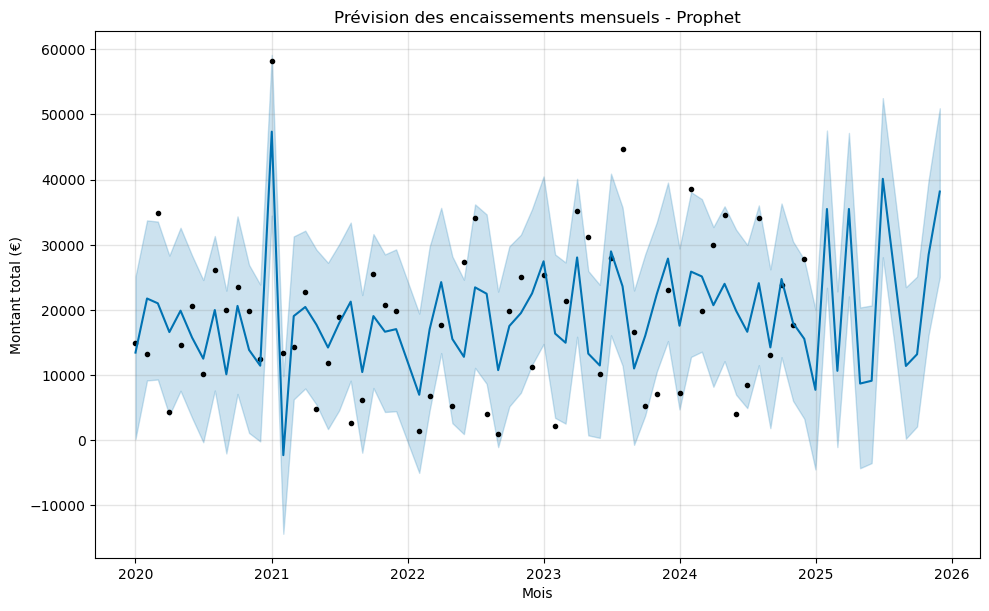

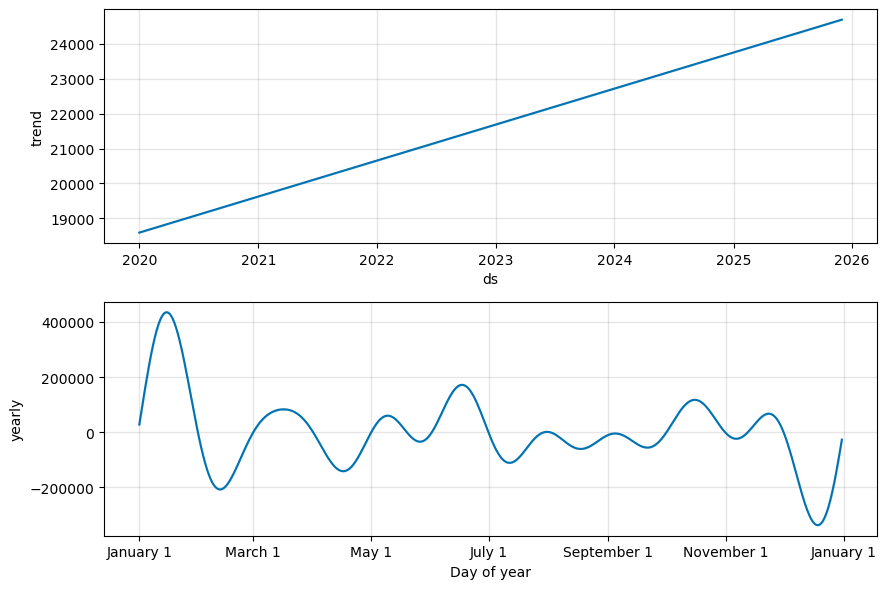

📏 Évaluation du modèle Prophet :
MAE  : 8053.43 €
RMSE : 9396.91 €
R²   : 0.2935


In [34]:
#hetha l algorithme 1 esmou prophet
# 📦 Imports
import pyodbc
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 🔗 Connexion à la base
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]

# ============ 🔮 PROPHET ================
model = Prophet()
model.fit(df)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# 📉 Graphique
fig1 = model.plot(forecast)
plt.title("Prévision des encaissements mensuels - Prophet")
plt.xlabel("Mois")
plt.ylabel("Montant total (€)")
plt.grid(True)
plt.show()

# 📉 Composantes Prophet
model.plot_components(forecast)
plt.show()

# 📏 Évaluation Prophet
y_true = df['y'][-12:]
y_pred = forecast['yhat'][-24:-12].values  # Derniers 12 mois historiques prévus

mae_p = mean_absolute_error(y_true, y_pred)
rmse_p = np.sqrt(mean_squared_error(y_true, y_pred))
r2_p = r2_score(y_true, y_pred)

print("📏 Évaluation du modèle Prophet :")
print("MAE  :", round(mae_p, 2), "€")
print("RMSE :", round(rmse_p, 2), "€")
print("R²   :", round(r2_p, 4))


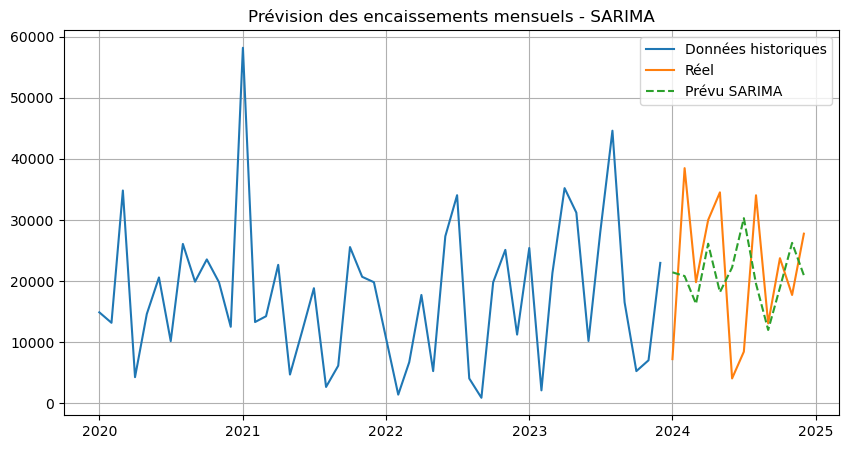

📏 Évaluation du modèle SARIMA :
MAE  : 10955.36 €
RMSE : 12819.01 €
R²   : -0.3148


In [35]:
#hetha l algorithme 2 esmou SARIMA
# 📚 Imports
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Connexion à la base (utilise celle que tu as déjà)
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 🧪 Split en train/test
train = df[:-12]
test = df[-12:]

# 📈 SARIMA Model (tu peux ajuster les paramètres p,d,q et saisonnier)
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_result = model.fit(disp=False)

# 🔮 Prévisions
forecast = sarima_result.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')

# 📉 Affichage
plt.figure(figsize=(10,5))
plt.plot(train.index, train['y'], label='Données historiques')
plt.plot(test.index, test['y'], label='Réel')
plt.plot(test.index, forecast, label='Prévu SARIMA', linestyle='--')
plt.title("Prévision des encaissements mensuels - SARIMA")
plt.legend()
plt.grid(True)
plt.show()

# 🧪 Évaluation
mae = mean_absolute_error(test['y'], forecast)
rmse = np.sqrt(mean_squared_error(test['y'], forecast))
r2 = r2_score(test['y'], forecast)

print("📏 Évaluation du modèle SARIMA :")
print("MAE  :", round(mae, 2), "€")
print("RMSE :", round(rmse, 2), "€")
print("R²   :", round(r2, 4))


C:\Users\Nour\AppData\Local\Temp\ipykernel_1836\51246308.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


📏 Évaluation XGBoost :
MAE  : 7125.37 €
RMSE : 8234.92 €
R²   : 0.4574


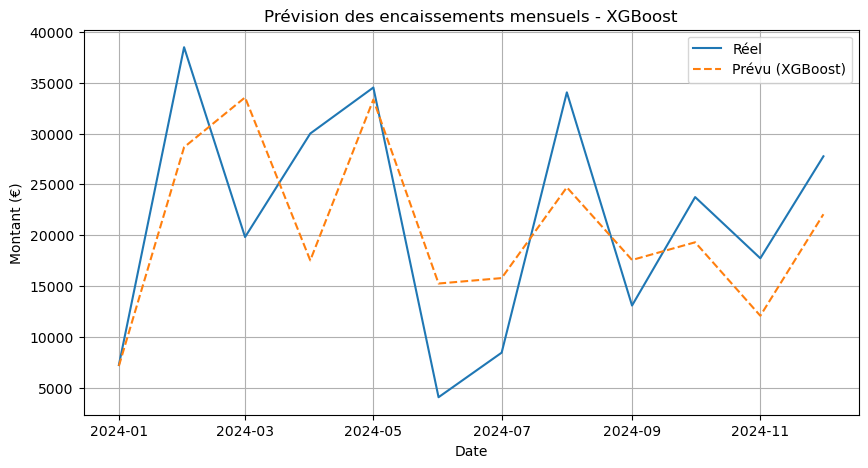

NameError: name 'xgb_model' is not defined

In [1]:
#hetha l algorithme 3 esmou XG BOOST
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

import joblib

# Connexion
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Données mensuelles
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 📐 Création de features temporelles
df['month'] = df.index.month
df['year'] = df.index.year
df['lag_1'] = df['y'].shift(1)
df['lag_2'] = df['y'].shift(2)
df['rolling_mean_3'] = df['y'].rolling(window=3).mean()
df.dropna(inplace=True)

# 🧪 Split train/test (12 derniers mois pour test)
train = df[:-12]
test = df[-12:]

X_train = train.drop(columns='y')
y_train = train['y']
X_test = test.drop(columns='y')
y_test = test['y']

# ⚙️ XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📉 Évaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📏 Évaluation XGBoost :")
print("MAE  :", round(mae, 2), "€")
print("RMSE :", round(rmse, 2), "€")
print("R²   :", round(r2, 4))

# 📊 Visualisation
plt.figure(figsize=(10,5))
plt.plot(test.index, y_test, label="Réel")
plt.plot(test.index, y_pred, label="Prévu (XGBoost)", linestyle="--")
plt.title("Prévision des encaissements mensuels - XGBoost")
plt.xlabel("Date")
plt.ylabel("Montant (€)")
plt.legend()
plt.grid(True)
plt.show()


# Supposons que ton modèle s'appelle xgb_model
joblib.dump(xgb_model, "xgboost_model.pkl")


C:\Users\Nour\AppData\Local\Temp\ipykernel_1836\746862128.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


📏 Évaluation XGBoost :
R²   : 0.4574


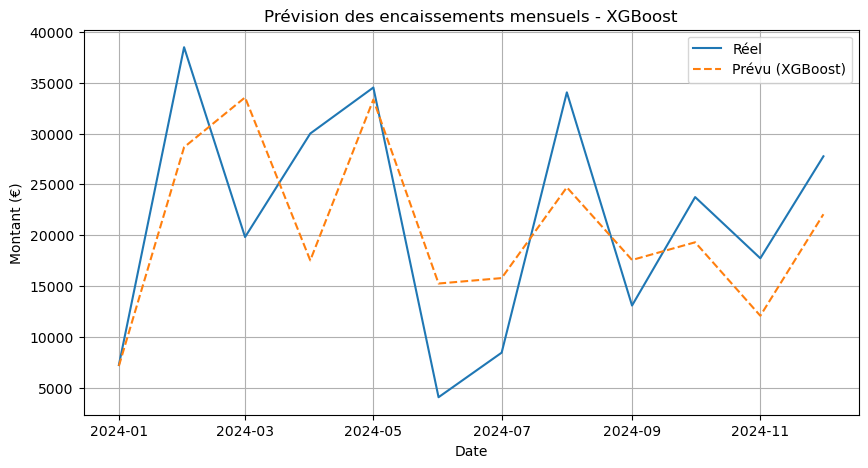

✅ Modèle sauvegardé sous 'xgboost_model.pkl'


In [3]:
# 📦 Importations
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import joblib

# 🔌 Connexion à la base de données
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📥 Requête SQL
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

# 🧹 Préparation des données
df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 🧠 Features temporelles
df['month'] = df.index.month
df['year'] = df.index.year
df['lag_1'] = df['y'].shift(1)
df['lag_2'] = df['y'].shift(2)
df['rolling_mean_3'] = df['y'].rolling(window=3).mean()
df.dropna(inplace=True)

# ✂️ Split train/test (12 derniers mois pour test)
train = df[:-12]
test = df[-12:]

X_train = train.drop(columns='y')
y_train = train['y']
X_test = test.drop(columns='y')
y_test = test['y']

# ⚙️ Entraînement XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 📊 Évaluation du modèle
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📏 Évaluation XGBoost :")

print("R²   :", round(r2, 4))

# 📈 Visualisation
plt.figure(figsize=(10, 5))
plt.plot(test.index, y_test, label="Réel")
plt.plot(test.index, y_pred, label="Prévu (XGBoost)", linestyle="--")
plt.title("Prévision des encaissements mensuels - XGBoost")
plt.xlabel("Date")
plt.ylabel("Montant (€)")
plt.legend()
plt.grid(True)
plt.show()

# 💾 Sauvegarde du modèle
joblib.dump(model, "xgboost_model.pkl")
print("✅ Modèle sauvegardé sous 'xgboost_model.pkl'")


C:\Users\Nour\AppData\Local\Temp\ipykernel_1836\4232686598.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\Nour\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


📏 Évaluation SGDRegressor :
R²   : 1.0


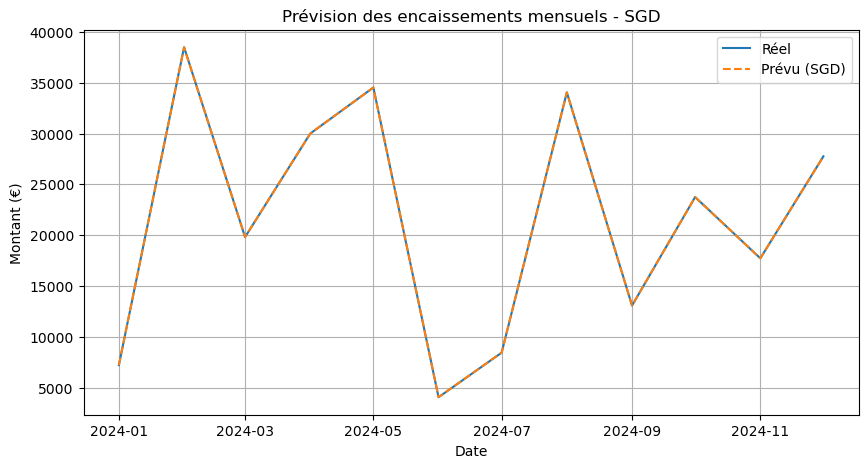

✅ Modèle sauvegardé sous 'sgd_model.pkl'


In [5]:
# 📦 Importations
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

# 🔌 Connexion à la base de données
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📥 Requête SQL
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

# 🧹 Préparation des données
df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 🧠 Features temporelles
df['month'] = df.index.month
df['year'] = df.index.year
df['lag_1'] = df['y'].shift(1)
df['lag_2'] = df['y'].shift(2)
df['rolling_mean_3'] = df['y'].rolling(window=3).mean()
df.dropna(inplace=True)

# ✂️ Split train/test
train = df[:-12]
test = df[-12:]

X_train = train.drop(columns='y')
y_train = train['y']
X_test = test.drop(columns='y')
y_test = test['y']

# 🔄 Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ⚙️ Entraînement SGDRegressor
model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# 📊 Évaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📏 Évaluation SGDRegressor :")

print("R²   :", round(r2, 4))

# 📈 Visualisation
plt.figure(figsize=(10, 5))
plt.plot(test.index, y_test, label="Réel")
plt.plot(test.index, y_pred, label="Prévu (SGD)", linestyle="--")
plt.title("Prévision des encaissements mensuels - SGD")
plt.xlabel("Date")
plt.ylabel("Montant (€)")
plt.legend()
plt.grid(True)
plt.show()

# 💾 Sauvegarde du modèle et du scaler
joblib.dump(model, "sgd_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Modèle sauvegardé sous 'sgd_model.pkl'")


C:\Users\Nour\AppData\Local\Temp\ipykernel_1836\1289127768.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\Nour\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1561: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


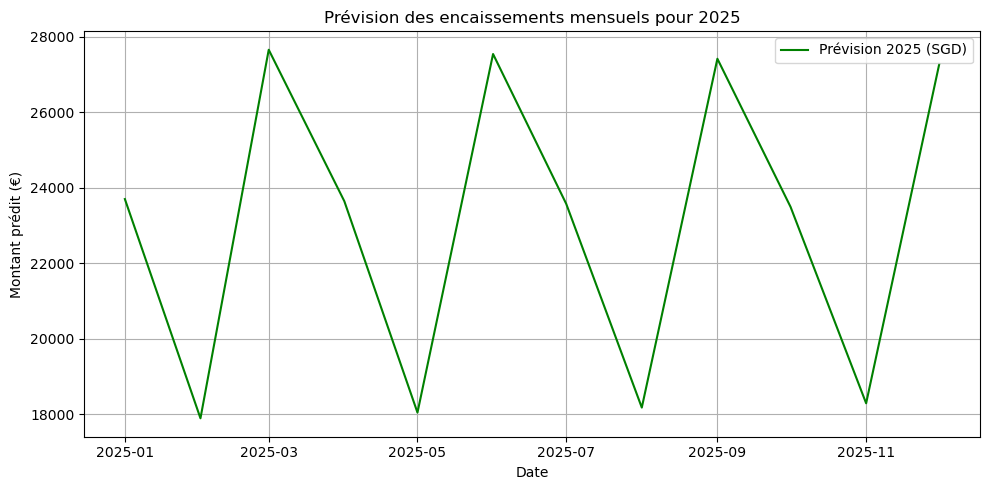

✅ Modèle et scaler sauvegardés.


In [12]:
# 📦 Importations
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

# 🔌 Connexion SQL
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📥 Requête SQL (historique jusqu’à fin 2024)
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

# 📊 Chargement des données
df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 🧠 Création des features temporelles
df['month'] = df.index.month
df['year'] = df.index.year
df['lag_1'] = df['y'].shift(1)
df['lag_2'] = df['y'].shift(2)
df['rolling_mean_3'] = df['y'].rolling(window=3).mean()
df.dropna(inplace=True)

# 🏋️‍♂️ Entraînement sur 2024
train = df[df.index.year == 2024]
X_train = train.drop(columns='y')
y_train = train['y']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X_train_scaled, y_train)

# 🔮 Prédiction mois par mois sur 2025
last_known = df.copy()
predictions = []

for month in pd.date_range("2025-01-01", "2025-12-01", freq='MS'):
    temp = {}
    temp['month'] = month.month
    temp['year'] = month.year
    temp['lag_1'] = last_known['y'].iloc[-1]
    temp['lag_2'] = last_known['y'].iloc[-2]
    temp['rolling_mean_3'] = last_known['y'].iloc[-3:].mean()
    
    X_pred = pd.DataFrame([temp])
    X_pred_scaled = scaler.transform(X_pred)
    
    y_pred = model.predict(X_pred_scaled)[0]
    predictions.append({'ds': month, 'y_pred': y_pred})
    
    # Ajouter la prédiction dans last_known pour les prochains mois
    new_row = pd.DataFrame({
        'y': [y_pred],
        'month': [month.month],
        'year': [month.year],
        'lag_1': [temp['lag_1']],
        'lag_2': [temp['lag_2']],
        'rolling_mean_3': [temp['rolling_mean_3']]
    }, index=[month])
    
    last_known = pd.concat([last_known, new_row])

# 📈 Affichage des prévisions
pred_df = pd.DataFrame(predictions)
pred_df.set_index('ds', inplace=True)

plt.figure(figsize=(10, 5))
plt.plot(pred_df.index, pred_df['y_pred'], label='Prévision 2025 (SGD)', color='green')
plt.title("Prévision des encaissements mensuels pour 2025")
plt.xlabel("Date")
plt.ylabel("Montant prédit (€)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 💾 Sauvegarde du modèle et du scaler
joblib.dump(model, "sgd_model_2025.pkl")
joblib.dump(scaler, "scaler_2025.pkl")
print("✅ Modèle et scaler sauvegardés.")


✅ Connexion réussie à la base DW_Fico
R²: 0.8390316776435673


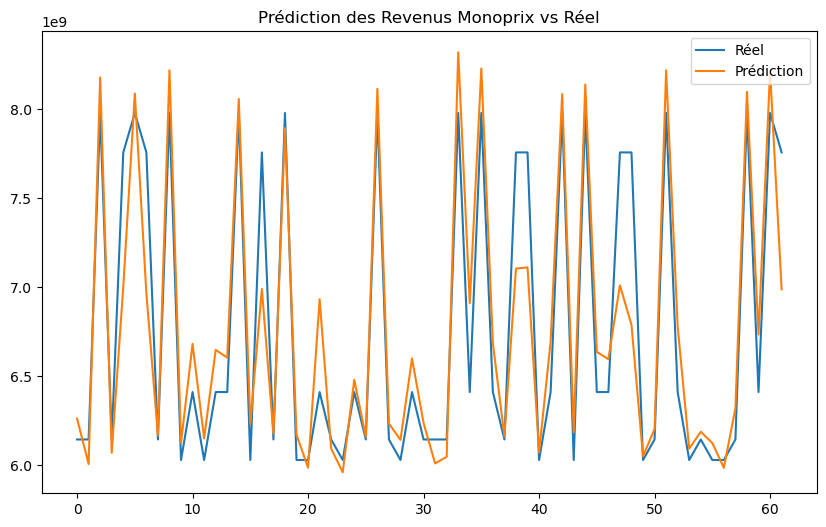

In [35]:
import pandas as pd
import pyodbc
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Supprimer les warnings
warnings.filterwarnings("ignore")

# Connexion SQL Server
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};SERVER={server};DATABASE={database};"
    f"UID={username};PWD={password};TrustServerCertificate=yes;MARS_Connection=yes;",
    timeout=5
)
print("✅ Connexion réussie à la base DW_Fico")

# Charger les données depuis SQL Server
query = "SELECT * FROM fact_fico"  # Remplace 'fact_fico' par le nom de ta table
df = pd.read_sql(query, conn)

# Supposons que tu veux prédire 'Revenu_monoprix' comme cible
X = df.drop(columns='Revenu_monoprix')  # Supprimer 'Revenu_monoprix' de X
y = df['Revenu_monoprix']  # Utiliser 'Revenu_monoprix' comme variable cible

# Scaler les données (important pour les algorithmes comme KMeans ou régressions)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialiser et entraîner un modèle de régression linéaire (par exemple)
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions et évaluation du modèle
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)


print(f"R²: {r2}")

# Afficher un graphique pour visualiser la prédiction
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Réel')
plt.plot(y_pred, label='Prédiction')
plt.legend()
plt.title("Prédiction des Revenus Monoprix vs Réel")
plt.show()


In [30]:
pip install tensorflow scikit-learn matplotlib pandas pyodbc


In [36]:
# 📦 Imports
import pyodbc
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 🔗 Connexion à la base de données
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]

# ============ 🔮 Prophet ================
model = Prophet()
model.fit(df)

# 🎯 Validation croisée
df_cv = cross_validation(
    model,
    initial='730 days',     # période d’entraînement initiale (~2 ans)
    period='30 days',       # fréquence des coupures
    horizon='365 days'      # prévision sur 1 an
)

# 📈 Évaluation des performances
df_p = performance_metrics(df_cv)

print("📊 Évaluation des performances de Prophet :")
print(df_p[['horizon', 'mae', 'rmse', 'mape', 'r2']])

# 📉 Visualisation des erreurs (optionnel)
from prophet.plot import plot_cross_validation_metric

# Visualisation du RMSE
fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.grid(True)
plt.show()

# ============ 📉 Graphique des prévisions ================
future = model.make_future_dataframe(df, periods=12, freq='M')
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title("Prévision des encaissements mensuels - Prophet")
plt.xlabel("Mois")
plt.ylabel("Montant total (€)")
plt.grid(True)
plt.show()

# 📉 Composantes Prophet
model.plot_components(forecast)
plt.show()

# 📏 Évaluation Prophet
y_true = df['y'][-12:]  # Derniers 12 mois de 2024
y_pred = forecast['yhat'][-24:-12].values  # Derniers 12 mois de la prévision

mae_p = mean_absolute_error(y_true, y_pred)
rmse_p = np.sqrt(mean_squared_error(y_true, y_pred))
r2_p = r2_score(y_true, y_pred)

print("📏 Évaluation du modèle Prophet (sur les derniers 12 mois de 2024) :")
print("MAE  :", round(mae_p, 2), "€")
print("RMSE :", round(rmse_p, 2), "€")
print("R²   :", round(r2_p, 4))


19:59:24 - cmdstanpy - INFO - Chain [1] start processing
19:59:25 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/24 [00:00<?, ?it/s]

19:59:25 - cmdstanpy - INFO - Chain [1] start processing
20:00:02 - cmdstanpy - INFO - Chain [1] done processing
20:00:02 - cmdstanpy - INFO - Chain [1] start processing
20:00:42 - cmdstanpy - INFO - Chain [1] done processing
20:00:42 - cmdstanpy - INFO - Chain [1] start processing
20:00:42 - cmdstanpy - INFO - Chain [1] done processing
20:00:42 - cmdstanpy - INFO - Chain [1] start processing
20:00:43 - cmdstanpy - INFO - Chain [1] done processing
20:00:43 - cmdstanpy - INFO - Chain [1] start processing
20:00:43 - cmdstanpy - INFO - Chain [1] done processing
20:00:43 - cmdstanpy - INFO - Chain [1] start processing
20:00:43 - cmdstanpy - INFO - Chain [1] done processing
20:00:44 - cmdstanpy - INFO - Chain [1] start processing
20:00:44 - cmdstanpy - INFO - Chain [1] done processing
20:00:44 - cmdstanpy - INFO - Chain [1] start processing
20:00:44 - cmdstanpy - INFO - Chain [1] done processing
20:00:44 - cmdstanpy - INFO - Chain [1] start processing
20:00:45 - cmdstanpy - INFO - Chain [1]

📊 Évaluation des performances de Prophet :


KeyError: "['r2'] not in index"

20:02:19 - cmdstanpy - INFO - Chain [1] start processing
20:02:19 - cmdstanpy - INFO - Chain [1] done processing


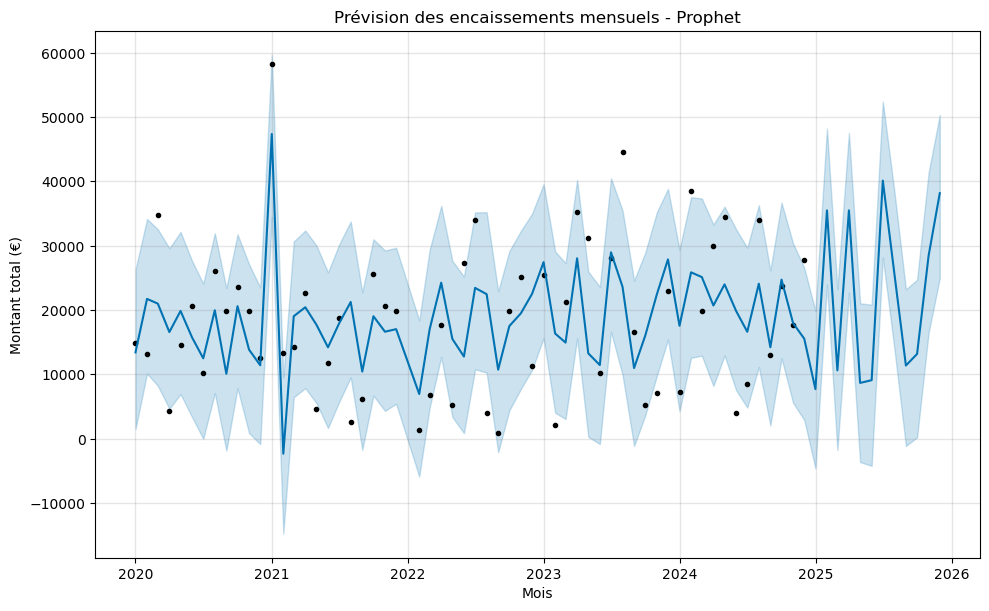

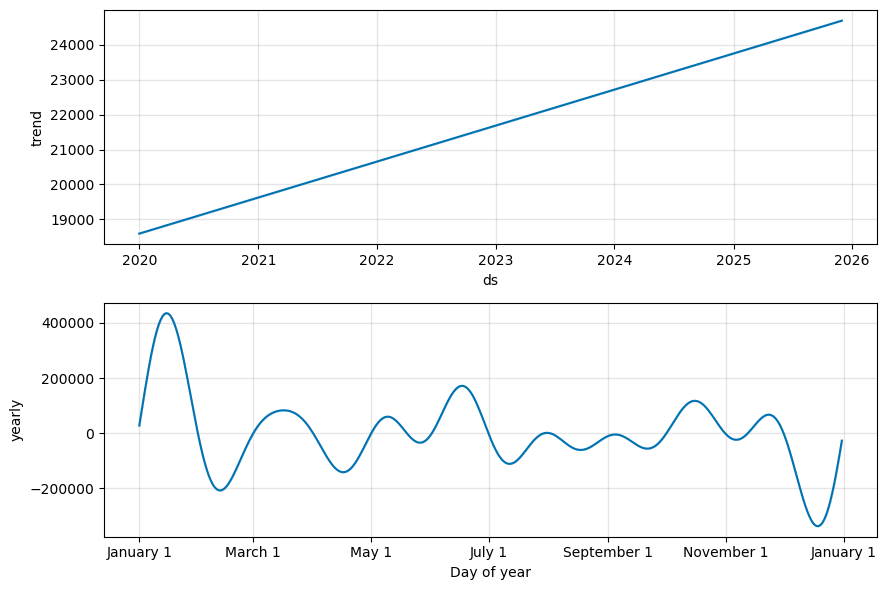

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/36 [00:00<?, ?it/s]

20:02:21 - cmdstanpy - INFO - Chain [1] start processing
20:02:22 - cmdstanpy - INFO - Chain [1] done processing
20:02:22 - cmdstanpy - INFO - Chain [1] start processing
20:02:23 - cmdstanpy - INFO - Chain [1] done processing
20:02:23 - cmdstanpy - INFO - Chain [1] start processing
20:02:25 - cmdstanpy - INFO - Chain [1] done processing
20:02:25 - cmdstanpy - INFO - Chain [1] start processing
20:02:25 - cmdstanpy - INFO - Chain [1] done processing
20:02:25 - cmdstanpy - INFO - Chain [1] start processing
20:02:26 - cmdstanpy - INFO - Chain [1] done processing
20:02:26 - cmdstanpy - INFO - Chain [1] start processing
20:02:43 - cmdstanpy - INFO - Chain [1] done processing
20:02:43 - cmdstanpy - INFO - Chain [1] start processing
20:02:45 - cmdstanpy - INFO - Chain [1] done processing
20:02:45 - cmdstanpy - INFO - Chain [1] start processing
20:02:52 - cmdstanpy - INFO - Chain [1] done processing
20:02:52 - cmdstanpy - INFO - Chain [1] start processing
20:03:14 - cmdstanpy - INFO - Chain [1]

📊 Évaluation des performances de Prophet :
     horizon           mae          rmse      mape
0    48 days  24563.363190  39009.791725  2.531908
1    49 days  20992.806036  33435.346256  2.261476
2    50 days  18475.095343  26603.733534  2.112333
3    51 days  18763.764304  26713.113257  2.086861
4    52 days  19087.134815  26946.044771  2.222386
..       ...           ...           ...       ...
175 361 days  16837.639146  21513.048109  1.714633
176 362 days  16390.136477  21138.580127  1.711500
177 363 days  16483.926535  21111.228016  1.676174
178 364 days  16709.960676  21154.595798  1.686724
179 365 days  15901.762456  20474.944380  1.667772

[180 rows x 4 columns]


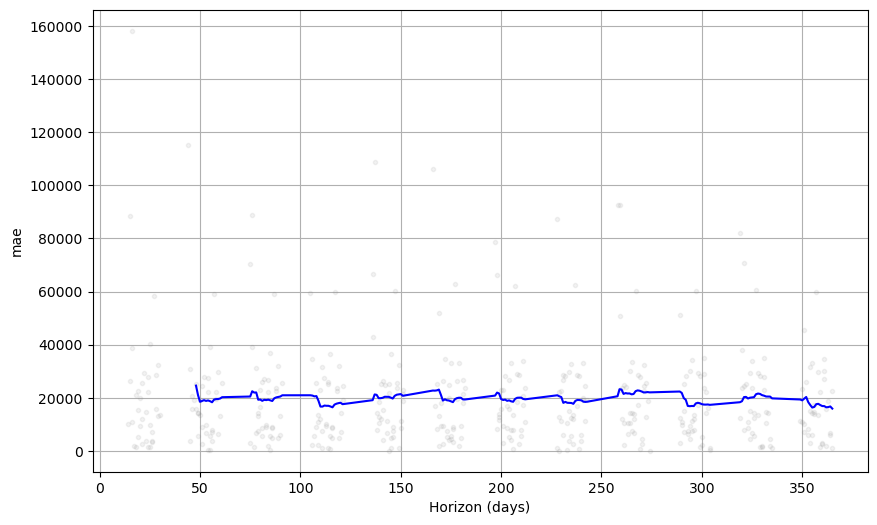

📏 La colonne 'r2' n'est pas disponible dans les résultats.


In [37]:
# 📦 Imports
import pyodbc
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 🔗 Connexion à la base
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]

# ============ 🔮 PROPHET ================
model = Prophet()
model.fit(df)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# 📉 Graphique de prévision
fig1 = model.plot(forecast)
plt.title("Prévision des encaissements mensuels - Prophet")
plt.xlabel("Mois")
plt.ylabel("Montant total (€)")
plt.grid(True)
plt.show()

# 📉 Composantes Prophet
model.plot_components(forecast)
plt.show()

# 📏 Évaluation des performances de Prophet avec Cross-Validation
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='365 days', period='30 days', horizon='365 days')
df_p = performance_metrics(df_cv)

# Affichage des résultats de l'évaluation (en excluant la colonne r2 si nécessaire)
print("📊 Évaluation des performances de Prophet :")
print(df_p[['horizon', 'mae', 'rmse', 'mape']])  # Ne pas inclure 'r2' si la colonne est absente

# 📉 Visualisation des erreurs
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='mae')
plt.show()

# 📏 Métriques additionnelles (si la colonne 'r2' est présente)
if 'r2' in df_p.columns:
    print("📏 R² des performances de Prophet :")
    print(df_p[['horizon', 'r2']])
else:
    print("📏 La colonne 'r2' n'est pas disponible dans les résultats.")


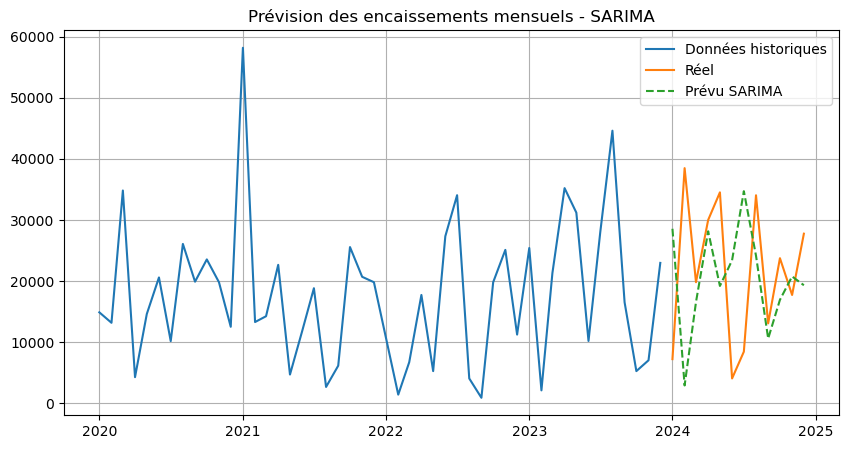

📏 Évaluation du modèle SARIMA :
R²   : -1.179


In [39]:
# 📚 Imports
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Connexion à la base (utilise celle que tu as déjà)
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-8COGQR0;"
    "DATABASE=DW_Fico;"
    "UID=PI_SA;"
    "PWD=Nour123;"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]
df.set_index('ds', inplace=True)

# 🧪 Split en train/test
train = df[:-12]
test = df[-12:]

# 📈 SARIMA Model (modifie les paramètres p, d, q, et saisonnier)
model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 1, 0, 12))  # Paramètres ajustés pour le test
sarima_result = model.fit(disp=False)

# 🔮 Prévisions
forecast = sarima_result.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')

# 📉 Affichage
plt.figure(figsize=(10,5))
plt.plot(train.index, train['y'], label='Données historiques')
plt.plot(test.index, test['y'], label='Réel')
plt.plot(test.index, forecast, label='Prévu SARIMA', linestyle='--')
plt.title("Prévision des encaissements mensuels - SARIMA")
plt.legend()
plt.grid(True)
plt.show()

# 🧪 Évaluation
mae = mean_absolute_error(test['y'], forecast)
rmse = np.sqrt(mean_squared_error(test['y'], forecast))
r2 = r2_score(test['y'], forecast)

print("📏 Évaluation du modèle SARIMA :")
print("R²   :", round(r2, 4))


Meilleur R² : 0.1308640679543187
Meilleurs paramètres : (3, 0, 1, 2, 1, 1)


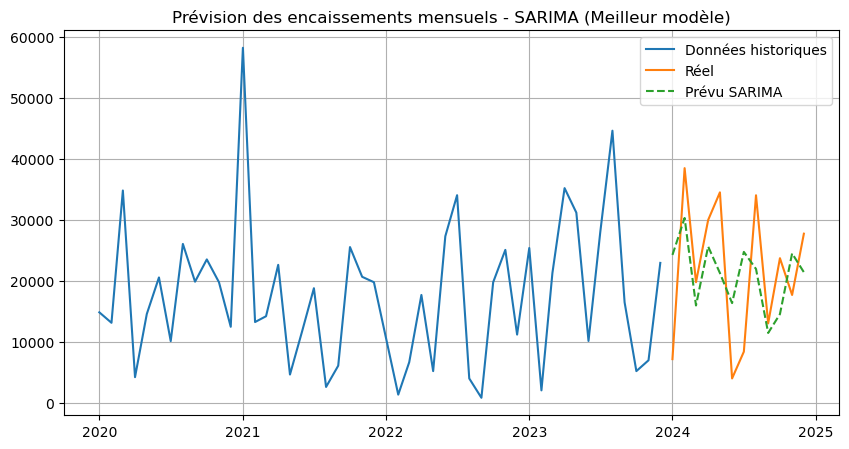

📏 Évaluation du modèle SARIMA :
MAE  : 9266.24 €
RMSE : 10422.38 €
R²   : 0.1309


In [40]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Listes des paramètres à tester
p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2]
seasonal_p_values = [0, 1, 2]
seasonal_d_values = [0, 1]
seasonal_q_values = [0, 1]
seasonal_s = [12]  # saisonnalité annuelle (12 mois)

best_r2 = float('-inf')
best_model = None

# Recherche par grille des meilleurs paramètres
for p in p_values:
    for d in d_values:
        for q in q_values:
            for sp in seasonal_p_values:
                for sd in seasonal_d_values:
                    for sq in seasonal_q_values:
                        try:
                            model = SARIMAX(train, order=(p, d, q), seasonal_order=(sp, sd, sq, 12))
                            sarima_result = model.fit(disp=False)
                            forecast = sarima_result.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')
                            r2 = r2_score(test['y'], forecast)

                            if r2 > best_r2:
                                best_r2 = r2
                                best_model = sarima_result
                                best_params = (p, d, q, sp, sd, sq)

                        except Exception as e:
                            # Si un paramètre échoue, on le capture
                            continue

print(f"Meilleur R² : {best_r2}")
print(f"Meilleurs paramètres : {best_params}")

# Utiliser le meilleur modèle pour les prévisions
forecast_best = best_model.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')

# Affichage
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['y'], label='Données historiques')
plt.plot(test.index, test['y'], label='Réel')
plt.plot(test.index, forecast_best, label='Prévu SARIMA', linestyle='--')
plt.title("Prévision des encaissements mensuels - SARIMA (Meilleur modèle)")
plt.legend()
plt.grid(True)
plt.show()

# Évaluation
mae = mean_absolute_error(test['y'], forecast_best)
rmse = np.sqrt(mean_squared_error(test['y'], forecast_best))
r2 = r2_score(test['y'], forecast_best)

print("📏 Évaluation du modèle SARIMA :")
print("MAE  :", round(mae, 2), "€")
print("RMSE :", round(rmse, 2), "€")
print("R²   :", round(r2, 4))


20:17:39 - cmdstanpy - INFO - Chain [1] start processing
20:17:39 - cmdstanpy - INFO - Chain [1] done processing


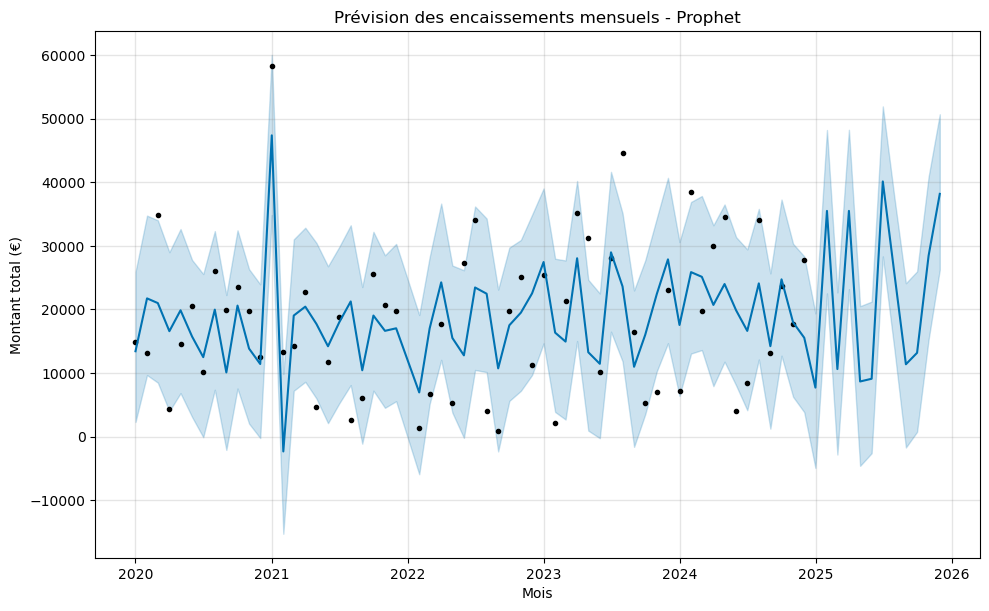

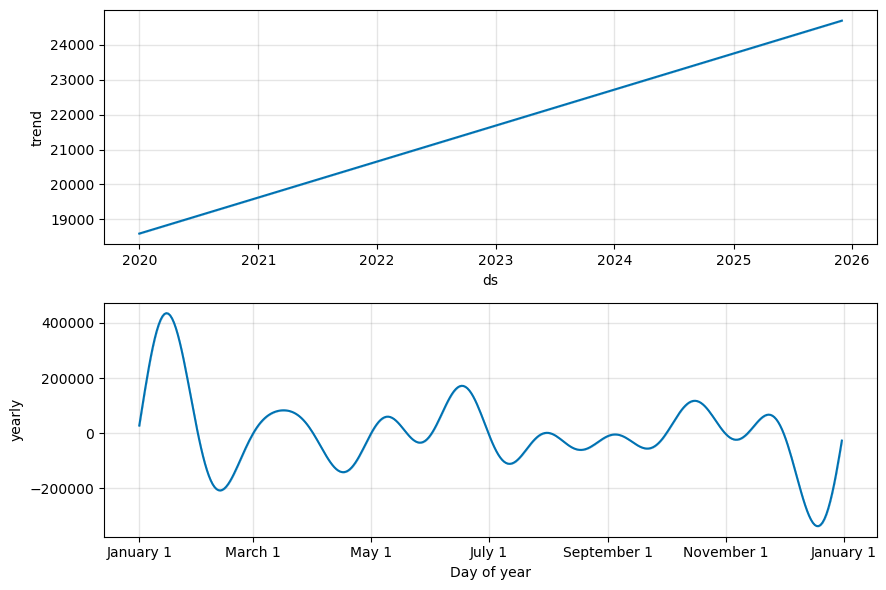

📏 Évaluation du modèle Prophet :
MAE  : 8053.43 €
RMSE : 9396.91 €
R²   : 0.2935
✅ Modèle Prophet sauvegardé sous 'prophet_model.pkl'


In [41]:
# 📦 Imports
import pyodbc
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib  # Importation de joblib pour la sauvegarde du modèle

# 🔗 Connexion à la base
server = 'DESKTOP-8COGQR0'
database = 'DW_Fico'
username = 'PI_SA'
password = 'Nour123'
driver = '{ODBC Driver 17 for SQL Server}'

conn = pyodbc.connect(
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    "TrustServerCertificate=yes;"
    "MARS_Connection=yes;"
)

# 📊 Extraction des encaissements mensuels
query = """
SELECT 
    FORMAT(d.date, 'yyyy-MM') AS mois,
    SUM(f.Amount_payement_Customer) AS montant_total
FROM FACT_Fico f
JOIN Dim_Date d ON f.FK_DatePayement = d.code_date
WHERE f.Amount_payement_Customer IS NOT NULL
GROUP BY FORMAT(d.date, 'yyyy-MM')
ORDER BY mois
"""

df = pd.read_sql(query, conn)
df['ds'] = pd.to_datetime(df['mois'])
df = df.rename(columns={"montant_total": "y"})
df = df[['ds', 'y']]

# ============ 🔮 PROPHET ================
model = Prophet()
model.fit(df)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# 📉 Graphique
fig1 = model.plot(forecast)
plt.title("Prévision des encaissements mensuels - Prophet")
plt.xlabel("Mois")
plt.ylabel("Montant total (€)")
plt.grid(True)
plt.show()

# 📉 Composantes Prophet
model.plot_components(forecast)
plt.show()

# 📏 Évaluation Prophet
y_true = df['y'][-12:]
y_pred = forecast['yhat'][-24:-12].values 

mae_p = mean_absolute_error(y_true, y_pred)
rmse_p = np.sqrt(mean_squared_error(y_true, y_pred))
r2_p = r2_score(y_true, y_pred)

print("📏 Évaluation du modèle Prophet :")
print("MAE  :", round(mae_p, 2), "€")
print("RMSE :", round(rmse_p, 2), "€")
print("R²   :", round(r2_p, 4))

# 💾 Sauvegarde du modèle Prophet en fichier .pkl
joblib.dump(model, 'prophet_model.pkl')
print("✅ Modèle Prophet sauvegardé sous 'prophet_model.pkl'")
